# 09 — Modern Pipeline Training: Frozen EfficientNet-B0 + Binary Head

This notebook implements the modern model required for Topic B:

- load the same train/validation/test split used by the classical HSV+GMM baseline;
- use a pretrained **EfficientNet-B0** backbone;
- freeze the backbone;
- train only a lightweight binary classification head;
- save validation/test logits and probabilities for ROC, calibration, and cost-sensitive decisions.

The target is `label = 1` for melanoma and `label = 0` for benign (nv, bkl, df, vasc).


In [1]:
import os
import sys
from pathlib import Path

# Robust project discovery: supports both
#   parent/skin_lesion/src/config.py
# and
#   project/src/config.py
_cwd = Path(os.getcwd()).resolve()
SRC_DIR = None
PROJECT_DIR = None
for _root in [_cwd, *_cwd.parents]:
    cand = _root / "skin_lesion" / "src" / "config.py"
    if cand.exists():
        SRC_DIR = cand.parent
        PROJECT_DIR = SRC_DIR.parent
        break
    cand = _root / "src" / "config.py"
    if cand.exists():
        SRC_DIR = cand.parent
        PROJECT_DIR = SRC_DIR.parent
        break

if SRC_DIR is None:
    raise FileNotFoundError(
        "Could not find src/config.py. Run this notebook from inside the project "
        "or from the parent folder containing skin_lesion/."
    )

sys.path.insert(0, str(SRC_DIR))

from config import SEED, COST_FN, COST_FP, MC_DROPOUT_T

# Use paths relative to the detected project folder. This avoids path issues
# if the zip is extracted either as skin_lesion/ or as the project root.
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
TABLES_DIR = PROJECT_DIR / "results" / "tables"
MODELS_DIR = PROJECT_DIR / "results" / "models"

for d in [PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR   : {PROJECT_DIR}")
print(f"RAW_DIR       : {RAW_DIR}")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"FIGURES_DIR   : {FIGURES_DIR}")
print(f"TABLES_DIR    : {TABLES_DIR}")
print(f"MODELS_DIR    : {MODELS_DIR}")

import random
import json
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm
from torchvision import transforms

from sklearn.metrics import roc_auc_score, accuracy_score

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else
    "cpu"
)
print(f"Device: {DEVICE}")


PROJECT_DIR   : /Users/thomasbove/Desktop/AIA_project/skin_lesion_project/skin_lesion
RAW_DIR       : /Users/thomasbove/Desktop/AIA_project/skin_lesion_project/skin_lesion/data/raw
PROCESSED_DIR : /Users/thomasbove/Desktop/AIA_project/skin_lesion_project/skin_lesion/data/processed
FIGURES_DIR   : /Users/thomasbove/Desktop/AIA_project/skin_lesion_project/skin_lesion/results/figures
TABLES_DIR    : /Users/thomasbove/Desktop/AIA_project/skin_lesion_project/skin_lesion/results/tables
MODELS_DIR    : /Users/thomasbove/Desktop/AIA_project/skin_lesion_project/skin_lesion/results/models


Device: mps


## 1 — Load split and metadata

This notebook requires `08_split_with_image_ids.ipynb` to have been run once.


In [2]:
split_path = PROCESSED_DIR / "splits_with_ids.npz"
if not split_path.exists():
    raise FileNotFoundError(
        f"Missing {split_path}. Run 08_split_with_image_ids.ipynb first."
    )

subset_path = PROCESSED_DIR / "balanced_subset.csv"
if not subset_path.exists():
    raise FileNotFoundError(
        f"Missing {subset_path}. Run 01_data_inspection.ipynb first."
    )

split_data = np.load(split_path, allow_pickle=True)
subset = pd.read_csv(subset_path)
subset["image_id"] = subset["image_id"].astype(str)

# Robust path resolver: use saved image_path if it still exists; otherwise scan RAW_DIR.
print("Indexing raw images for path fallback...")
image_index = {p.stem: p for p in RAW_DIR.rglob("*.jpg")}
print(f"Found {len(image_index)} jpg files under RAW_DIR")

def resolve_image_path(row):
    p = row.get("image_path", None)
    if isinstance(p, str) and Path(p).exists():
        return p
    fallback = image_index.get(str(row["image_id"]))
    return str(fallback) if fallback is not None else None

subset["image_path_resolved"] = subset.apply(resolve_image_path, axis=1)
missing = subset["image_path_resolved"].isna().sum()
print(f"Missing resolved paths: {missing} / {len(subset)}")
if missing:
    print(subset.loc[subset["image_path_resolved"].isna(), ["image_id", "label"]].head())

def make_split_df(split_name):
    ids = split_data[f"ids_{split_name}"].astype(str)
    yy = split_data[f"y_{split_name}"].astype(int)
    df = pd.DataFrame({"image_id": ids, "label_from_split": yy})
    df = df.merge(subset, on="image_id", how="left")
    # Prefer the split label because it is guaranteed to match the classical features.
    df["label"] = df["label_from_split"].astype(int)
    df["split"] = split_name
    df["image_path"] = df["image_path_resolved"]
    return df[["image_id", "image_path", "label", "split"]]

train_df = make_split_df("train")
val_df   = make_split_df("val")
test_df  = make_split_df("test")

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: n={len(df)}, missing paths={df['image_path'].isna().sum()}, "
          f"melanoma={int(df['label'].sum())}, benign={int((df['label']==0).sum())}")

assert train_df["image_path"].notna().all(), "Some train images could not be resolved."
assert val_df["image_path"].notna().all(), "Some validation images could not be resolved."
assert test_df["image_path"].notna().all(), "Some test images could not be resolved."


Indexing raw images for path fallback...
Found 10015 jpg files under RAW_DIR
Missing resolved paths: 0 / 2226
train: n=1335, missing paths=0, melanoma=667, benign=668
val  : n=445, missing paths=0, melanoma=223, benign=222
test : n=446, missing paths=0, melanoma=223, benign=223


## 2 — PyTorch dataset and transforms

We keep augmentations conservative because dermoscopy colour and lesion boundaries may be clinically meaningful. The validation and test transforms are deterministic.


In [3]:
# ImageNet normalization expected by pretrained EfficientNet models.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class SkinLesionDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = torch.tensor(float(row["label"]), dtype=torch.float32)
        return image, label, row["image_id"]

BATCH_SIZE = 32
NUM_WORKERS = 0  # set to 2 or 4 on Linux if desired

train_ds = SkinLesionDataset(train_df, train_tfms)
val_ds   = SkinLesionDataset(val_df,   eval_tfms)
test_ds  = SkinLesionDataset(test_df,  eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

xb, yb, idsb = next(iter(train_loader))
print(f"Batch image tensor: {xb.shape}")
print(f"Batch labels      : {yb.shape}, positives={int(yb.sum())}")
print(f"First IDs         : {list(idsb)[:3]}")


Batch image tensor: torch.Size([32, 3, 224, 224])
Batch labels      : torch.Size([32]), positives=18
First IDs         : ['ISIC_0028874', 'ISIC_0029821', 'ISIC_0032690']


## 3 — Build EfficientNet-B0 with a trainable binary head

The backbone is frozen. Only the final classification head is trained.


In [4]:
def build_efficientnet_b0_binary(dropout_p=0.20):
    weights = tvm.EfficientNet_B0_Weights.DEFAULT
    model = tvm.efficientnet_b0(weights=weights)

    # Freeze pretrained backbone and original classifier parameters first.
    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, 1),
    )
    return model

model = build_efficientnet_b0_binary(dropout_p=0.20).to(DEVICE)

n_total = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {n_total:,}")
print(f"Trainable parameters : {n_trainable:,}")
for name, p in model.named_parameters():
    if p.requires_grad:
        print(f"  trainable: {name:35s} {tuple(p.shape)}")


Total parameters     : 4,008,829
Trainable parameters : 1,281
  trainable: classifier.1.weight                 (1, 1280)
  trainable: classifier.1.bias                   (1,)


## 4 — Training utilities

We train with binary cross-entropy on logits. Metrics are computed from `sigmoid(logit)`.


In [5]:
def compute_auc_safe(labels, probs):
    labels = np.asarray(labels)
    probs = np.asarray(probs)
    if len(np.unique(labels)) < 2:
        return np.nan
    return roc_auc_score(labels, probs)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    n_samples = 0
    all_logits, all_labels, all_ids = [], [], []

    for images, labels, image_ids in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        bs = labels.size(0)
        total_loss += float(loss.item()) * bs
        n_samples += bs
        all_logits.append(logits.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())
        all_ids.extend(list(image_ids))

    logits = np.concatenate(all_logits)
    labels = np.concatenate(all_labels).astype(int)
    probs = 1.0 / (1.0 + np.exp(-logits))

    metrics = {
        "loss": total_loss / max(n_samples, 1),
        "auc": compute_auc_safe(labels, probs),
        "accuracy_05": accuracy_score(labels, (probs >= 0.5).astype(int)),
        "logits": logits,
        "probs": probs,
        "labels": labels,
        "image_ids": np.array(all_ids),
    }
    return metrics


## 5 — Optional sanity check: overfit a tiny subset

If this cell cannot overfit a tiny dataset, something is wrong with image loading, labels, or the model head. Leave `RUN_TINY_OVERFIT = False` during normal runs.


In [6]:
RUN_TINY_OVERFIT = False

if RUN_TINY_OVERFIT:
    tiny_df = pd.concat([
        train_df[train_df["label"] == 0].head(8),
        train_df[train_df["label"] == 1].head(8),
    ]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    tiny_ds = SkinLesionDataset(tiny_df, train_tfms)
    tiny_loader = DataLoader(tiny_ds, batch_size=8, shuffle=True, num_workers=NUM_WORKERS)

    tiny_model = build_efficientnet_b0_binary(dropout_p=0.0).to(DEVICE)
    tiny_criterion = nn.BCEWithLogitsLoss()
    tiny_optimizer = torch.optim.AdamW(
        [p for p in tiny_model.parameters() if p.requires_grad], lr=1e-2, weight_decay=0.0
    )
    for epoch in range(1, 31):
        tr = run_epoch(tiny_model, tiny_loader, tiny_criterion, tiny_optimizer)
        if epoch % 5 == 0 or epoch == 1:
            print(f"epoch {epoch:02d} | loss={tr['loss']:.4f} | acc={tr['accuracy_05']:.3f} | auc={tr['auc']:.3f}")
else:
    print("Tiny overfit check skipped. Set RUN_TINY_OVERFIT=True for debugging.")


Tiny overfit check skipped. Set RUN_TINY_OVERFIT=True for debugging.


## 6 — Train the modern model

The validation set selects the best checkpoint. The test set is not used here.


In [7]:
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 30
PATIENCE = 6
MIN_DELTA = 1e-4

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

history = []
best_state = None
best_val_auc = -np.inf
best_epoch = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer)
    val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_auc": train_metrics["auc"],
        "train_acc_05": train_metrics["accuracy_05"],
        "val_loss": val_metrics["loss"],
        "val_auc": val_metrics["auc"],
        "val_acc_05": val_metrics["accuracy_05"],
    }
    history.append(row)

    improved = val_metrics["auc"] > best_val_auc + MIN_DELTA
    if improved:
        best_val_auc = val_metrics["auc"]
        best_epoch = epoch
        best_state = deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"epoch {epoch:02d} | "
        f"train loss={row['train_loss']:.4f}, auc={row['train_auc']:.4f}, acc={row['train_acc_05']:.4f} | "
        f"val loss={row['val_loss']:.4f}, auc={row['val_auc']:.4f}, acc={row['val_acc_05']:.4f}" +
        ("  <-- best" if improved else "")
    )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping after {epoch} epochs. Best epoch: {best_epoch}, val AUC={best_val_auc:.4f}")
        break

if best_state is None:
    best_state = deepcopy(model.state_dict())
    best_epoch = len(history)

model.load_state_dict(best_state)
print(f"Loaded best checkpoint from epoch {best_epoch} with val AUC={best_val_auc:.4f}")


epoch 01 | train loss=0.6008, auc=0.7785, acc=0.7086 | val loss=0.5711, auc=0.7762, acc=0.7303  <-- best


epoch 02 | train loss=0.5119, auc=0.8375, acc=0.7730 | val loss=0.5460, auc=0.7912, acc=0.7326  <-- best


epoch 03 | train loss=0.4847, auc=0.8474, acc=0.7835 | val loss=0.5400, auc=0.7961, acc=0.7438  <-- best


epoch 04 | train loss=0.4722, auc=0.8585, acc=0.7775 | val loss=0.5456, auc=0.7972, acc=0.7258  <-- best


epoch 05 | train loss=0.4506, auc=0.8731, acc=0.7978 | val loss=0.5429, auc=0.7996, acc=0.7281  <-- best


...

epoch 13 | train loss=0.4155, auc=0.8918, acc=0.8067 | val loss=0.5473, auc=0.8002, acc=0.7303


epoch 14 | train loss=0.4108, auc=0.8941, acc=0.8090 | val loss=0.5443, auc=0.8007, acc=0.7393


epoch 15 | train loss=0.4053, auc=0.8957, acc=0.8187 | val loss=0.5541, auc=0.7977, acc=0.7258


epoch 16 | train loss=0.3995, auc=0.9011, acc=0.8187 | val loss=0.5551, auc=0.7943, acc=0.7258


epoch 17 | train loss=0.4000, auc=0.8982, acc=0.8142 | val loss=0.5497, auc=0.8013, acc=0.7326
Early stopping after 17 epochs. Best epoch: 11, val AUC=0.8024
Loaded best checkpoint from epoch 11 with val AUC=0.8024


## 7 — Save checkpoint and training history


Saved history to: /Users/thomasbove/Desktop/AIA_project/skin_lesion_project/skin_lesion/results/tables/modern_training_history.csv
Saved best checkpoint to: /Users/thomasbove/Desktop/AIA_project/skin_lesion_project/skin_lesion/results/models/efficientnet_b0_frozen_head.pt


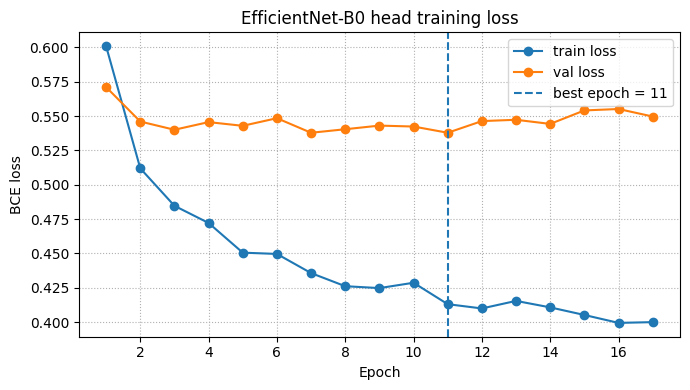

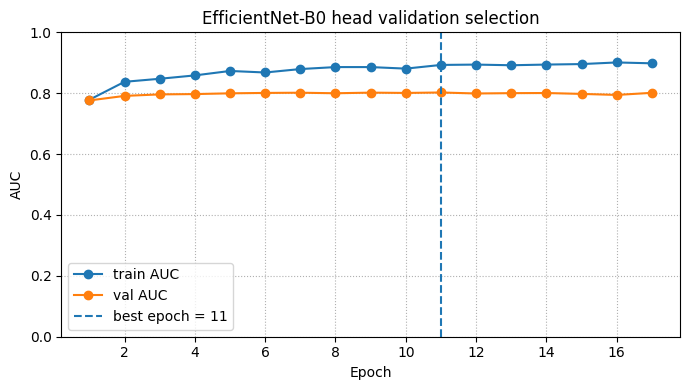

In [8]:
history_df = pd.DataFrame(history)
history_path = TABLES_DIR / "modern_training_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to: {history_path}")

ckpt = {
    "model_name": "efficientnet_b0_frozen_binary_head",
    "state_dict": model.state_dict(),
    "best_epoch": best_epoch,
    "best_val_auc": float(best_val_auc),
    "seed": SEED,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "dropout_p": 0.20,
    "class_mapping": {"benign": 0, "melanoma": 1},
}
ckpt_path = MODELS_DIR / "efficientnet_b0_frozen_head.pt"
torch.save(ckpt, ckpt_path)
print(f"Saved best checkpoint to: {ckpt_path}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val loss")
ax.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE loss")
ax.set_title("EfficientNet-B0 head training loss")
ax.grid(True, linestyle=":")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df["epoch"], history_df["train_auc"], marker="o", label="train AUC")
ax.plot(history_df["epoch"], history_df["val_auc"], marker="o", label="val AUC")
ax.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
ax.set_xlabel("Epoch")
ax.set_ylabel("AUC")
ax.set_ylim(0.0, 1.0)
ax.set_title("EfficientNet-B0 head validation selection")
ax.grid(True, linestyle=":")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "modern_training_auc.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 — Save validation and test predictions

The next notebook uses these logits for ROC curves, cost-sensitive thresholds, reliability diagrams, ECE, and temperature scaling.


In [9]:
val_metrics = run_epoch(model, val_loader, criterion, optimizer=None)
test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)

print(f"Validation AUC: {val_metrics['auc']:.4f}, acc@0.5={val_metrics['accuracy_05']:.4f}")
print(f"Test AUC      : {test_metrics['auc']:.4f}, acc@0.5={test_metrics['accuracy_05']:.4f}")

def predictions_dataframe(metrics, split_name):
    return pd.DataFrame({
        "image_id": metrics["image_ids"].astype(str),
        "split": split_name,
        "label": metrics["labels"].astype(int),
        "logit": metrics["logits"].astype(float),
        "prob_melanoma": metrics["probs"].astype(float),
    })

val_pred = predictions_dataframe(val_metrics, "val")
test_pred = predictions_dataframe(test_metrics, "test")

val_path = PROCESSED_DIR / "efficientnet_predictions_val.csv"
test_path = PROCESSED_DIR / "efficientnet_predictions_test.csv"
val_pred.to_csv(val_path, index=False)
test_pred.to_csv(test_path, index=False)
print(f"Saved validation predictions to: {val_path}")
print(f"Saved test predictions to      : {test_path}")

print(test_pred.head())


Validation AUC: 0.8024, acc@0.5=0.7303
Test AUC      : 0.8679, acc@0.5=0.7982
Saved validation predictions to: /Users/thomasbove/Desktop/AIA_project/skin_lesion_project/skin_lesion/data/processed/efficientnet_predictions_val.csv
Saved test predictions to      : /Users/thomasbove/Desktop/AIA_project/skin_lesion_project/skin_lesion/data/processed/efficientnet_predictions_test.csv
       image_id split  label     logit  prob_melanoma
0  ISIC_0026993  test      1  4.309456       0.986737
1  ISIC_0029512  test      1 -0.238186       0.440734
2  ISIC_0027872  test      1  0.430224       0.605927
3  ISIC_0025303  test      1  0.720228       0.672657
4  ISIC_0030129  test      1  0.394671       0.597407
